# 스마트 창고 출고 지연 예측 — EDA

**목표**: 데이터 구조 파악 → 결측값 분석 → 타겟 분포 → 피처 분석 → 시계열 패턴 → 레이아웃 분석 → 상관관계

## 0. 라이브러리 로드

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

SEED = 42
TARGET = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

## 1. 데이터 로드

In [4]:
train = pd.read_csv('./open/train.csv')
test  = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

print(f'train : {train.shape}')
print(f'test  : {test.shape}')
print(f'layout: {layout.shape}')

train : (250000, 94)
test  : (50000, 93)
layout: (300, 15)


In [5]:
train.head(3)

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40


In [6]:
layout.head(3)

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2


## 2. 기본 정보

In [7]:
print('=== dtypes 분포 ===')
print(train.dtypes.value_counts())

print('\n=== 수치형 기술 통계 ===')
train.describe().T.style.background_gradient(cmap='Blues')

=== dtypes 분포 ===
float64    88
str         3
int64       3
Name: count, dtype: int64

=== 수치형 기술 통계 ===


,count,mean,std,min,25%,50%,75%,max
order_inflow_15m,220436.000000,94.585662,77.083546,0.000000,29.000000,78.000000,142.000000,477.000000
unique_sku_15m,220076.000000,108.275673,105.558290,0.000000,37.000000,73.000000,141.000000,500.000000
avg_items_per_order,220377.000000,3.473318,2.190259,1.000000,1.460000,2.840000,4.980000,15.000000
urgent_order_ratio,220246.000000,0.112411,0.108145,0.000000,0.023300,0.081100,0.179900,1.000000
heavy_item_ratio,220384.000000,0.179021,0.111210,0.000000,0.100000,0.176500,0.254600,1.000000
cold_chain_ratio,220549.000000,0.094962,0.081449,0.000000,0.026000,0.083300,0.144400,0.500000
sku_concentration,220301.000000,0.425110,0.192997,0.100000,0.268500,0.399300,0.557000,0.900000
robot_active,250000.000000,13.379388,11.449100,0.000000,4.000000,10.000000,19.000000,79.000000
robot_idle,250000.000000,25.813408,22.687023,0.000000,2.000000,23.000000,45.000000,80.000000
robot_charging,250000.000000,6.128704,12.433735,0.000000,0.000000,0.000000,6.000000,80.000000


In [8]:
# 시나리오 / 창고 수
print(f'고유 scenario_id 수: {train["scenario_id"].nunique():,}')
print(f'고유 layout_id    수: {train["layout_id"].nunique():,}')
print(f'시나리오당 평균 행 수: {len(train) / train["scenario_id"].nunique():.1f}')

ts_counts = train.groupby('scenario_id').size()
print(f'\n타임스텝 분포: min={ts_counts.min()} / median={ts_counts.median()} / max={ts_counts.max()}')

고유 scenario_id 수: 10,000
고유 layout_id    수: 250
시나리오당 평균 행 수: 25.0

타임스텝 분포: min=25 / median=25.0 / max=25


## 3. 결측값 분석

In [9]:
feat_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]

miss = train[feat_cols].isnull().sum().sort_values(ascending=False)
miss_pct = miss / len(train) * 100
miss_df = pd.DataFrame({'결측 수': miss, '결측률(%)': miss_pct}).query('`결측 수` > 0')

print(f'결측값 있는 피처: {len(miss_df)} / {len(feat_cols)}')
miss_df.head(20)

결측값 있는 피처: 86 / 90


,결측 수,결측률(%)
avg_recovery_time,32529,13.0116
congestion_score,32250,12.9000
avg_charge_wait,30696,12.2784
battery_mean,30320,12.1280
charge_efficiency_pct,30052,12.0208
battery_cycle_count_avg,29955,11.9820
fleet_age_months_avg,29953,11.9812
robot_calibration_score,29944,11.9776
unique_sku_15m,29924,11.9696
staging_area_util,29892,11.9568


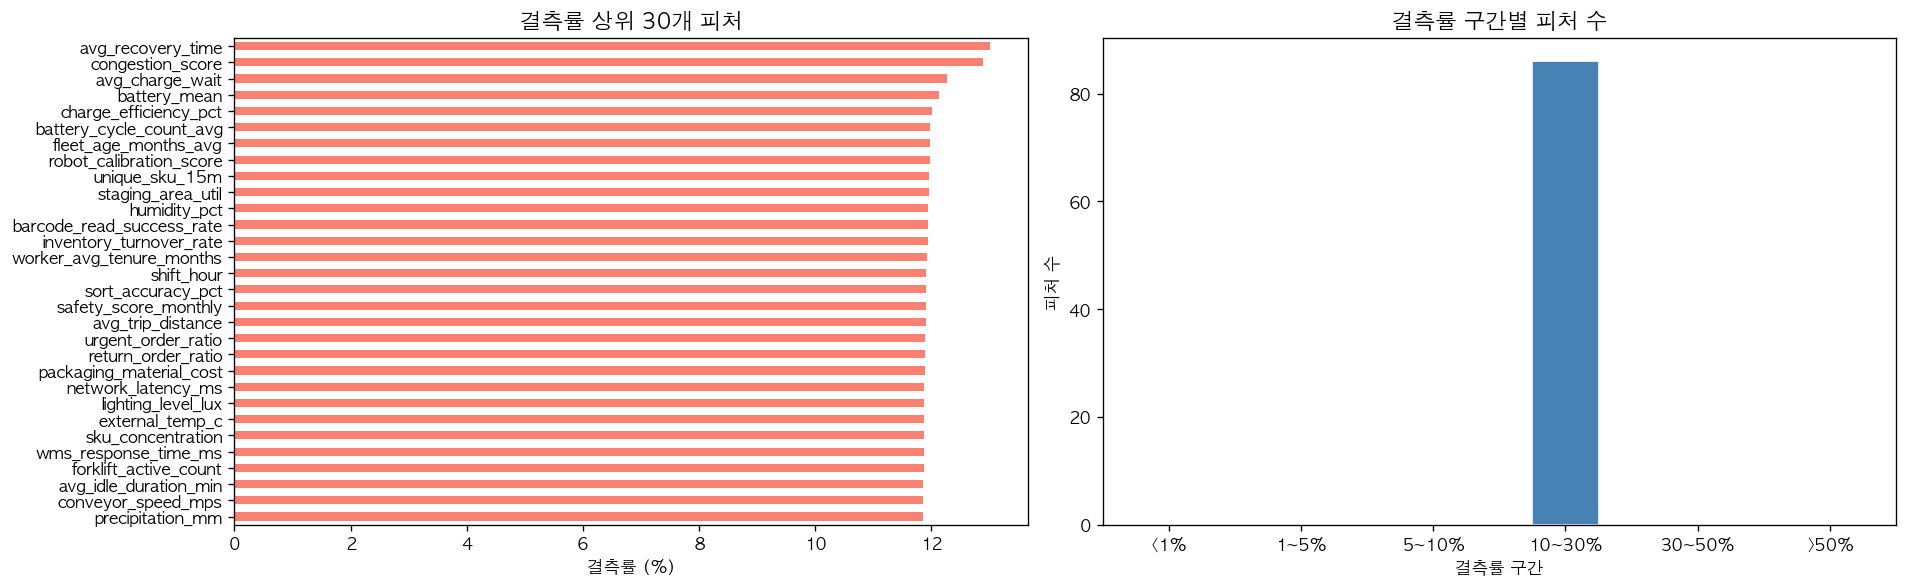

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 결측률 bar
miss_df['결측률(%)'].head(30).sort_values().plot(
    kind='barh', ax=axes[0], color='salmon'
)
axes[0].set_title('결측률 상위 30개 피처', fontsize=13)
axes[0].set_xlabel('결측률 (%)')

# 결측률 구간별 피처 수
bins = [0, 1, 5, 10, 30, 50, 100]
labels = ['<1%', '1~5%', '5~10%', '10~30%', '30~50%', '>50%']
buckets = pd.cut(miss_pct[miss_pct > 0], bins=bins, labels=labels)
buckets.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('결측률 구간별 피처 수', fontsize=13)
axes[1].set_xlabel('결측률 구간')
axes[1].set_ylabel('피처 수')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. 타겟 변수 분석

In [11]:
y = train[TARGET]
print('=== 타겟 기술 통계 ===')
print(y.describe())
print(f'\n왜도(skewness) : {y.skew():.4f}')
print(f'첨도(kurtosis) : {y.kurt():.4f}')
print(f'0 이하 비율    : {(y <= 0).mean()*100:.2f}%')

=== 타겟 기술 통계 ===
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64

왜도(skewness) : 5.6821
첨도(kurtosis) : 64.0477
0 이하 비율    : 2.73%


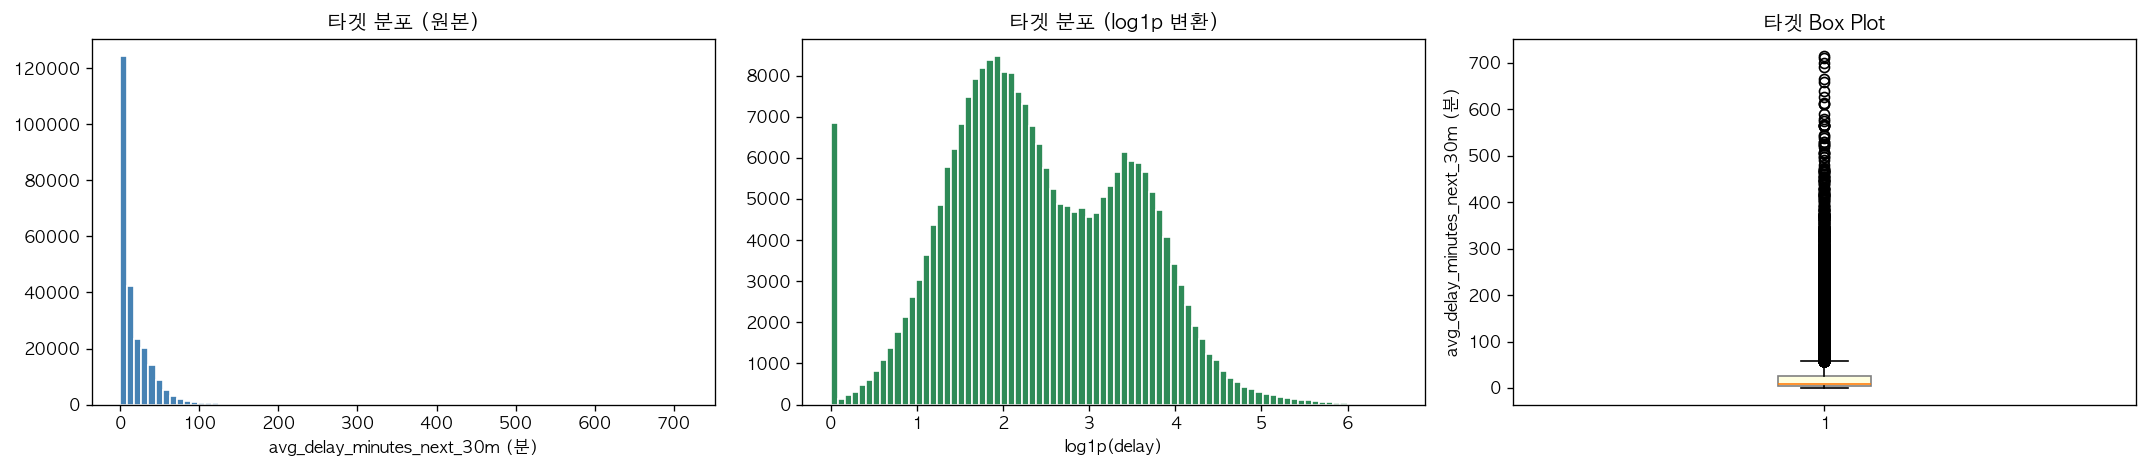

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 원본 분포
axes[0].hist(y, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('타겟 분포 (원본)', fontsize=12)
axes[0].set_xlabel('avg_delay_minutes_next_30m (분)')

# log1p 분포
axes[1].hist(np.log1p(y.clip(lower=0)), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('타겟 분포 (log1p 변환)', fontsize=12)
axes[1].set_xlabel('log1p(delay)')

# Box plot
axes[2].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightyellow', color='gray'))
axes[2].set_title('타겟 Box Plot', fontsize=12)
axes[2].set_ylabel('avg_delay_minutes_next_30m (분)')

plt.tight_layout()
plt.show()

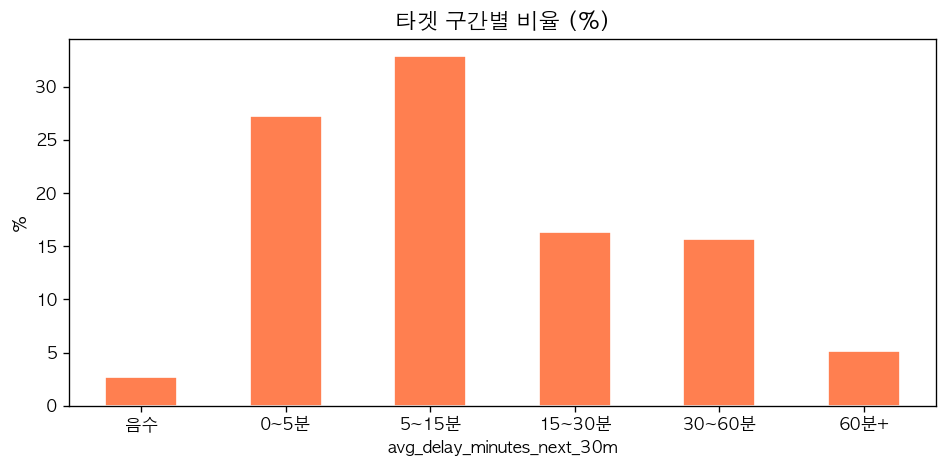

avg_delay_minutes_next_30m
음수         2.73
0~5분      27.29
5~15분     32.85
15~30분    16.29
30~60분    15.67
60분+       5.17


In [13]:
# 타겟 구간별 비율
bins = [y.min()-0.01, 0, 5, 15, 30, 60, y.max()+0.01]
labels = ['음수', '0~5분', '5~15분', '15~30분', '30~60분', '60분+']
bucket = pd.cut(y, bins=bins, labels=labels)
pct = bucket.value_counts(normalize=True).sort_index() * 100

pct.plot(kind='bar', color='coral', edgecolor='white', figsize=(8, 4))
plt.title('타겟 구간별 비율 (%)', fontsize=13)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(pct.round(2).to_string())

## 5. 시계열 패턴 분석

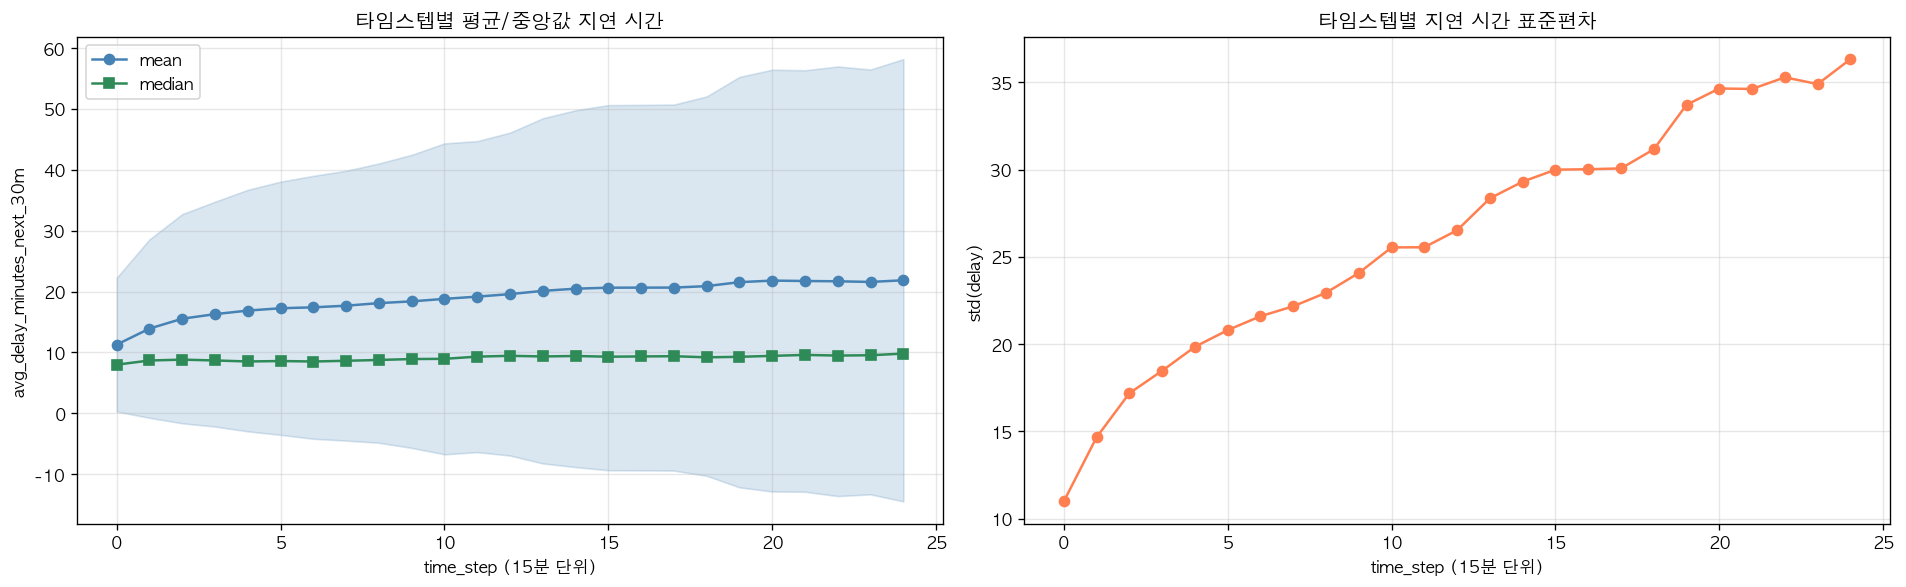

In [14]:
# 타임스텝(순번) 계산: 시나리오 내 행 순서
train['time_step'] = train.groupby('scenario_id').cumcount()

ts_stats = train.groupby('time_step')[TARGET].agg(['mean', 'median', 'std']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ts_stats['time_step'], ts_stats['mean'], marker='o', color='steelblue', label='mean')
axes[0].plot(ts_stats['time_step'], ts_stats['median'], marker='s', color='seagreen', label='median')
axes[0].fill_between(
    ts_stats['time_step'],
    ts_stats['mean'] - ts_stats['std'],
    ts_stats['mean'] + ts_stats['std'],
    alpha=0.2, color='steelblue'
)
axes[0].set_title('타임스텝별 평균/중앙값 지연 시간', fontsize=12)
axes[0].set_xlabel('time_step (15분 단위)')
axes[0].set_ylabel('avg_delay_minutes_next_30m')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ts_stats['time_step'], ts_stats['std'], marker='o', color='coral')
axes[1].set_title('타임스텝별 지연 시간 표준편차', fontsize=12)
axes[1].set_xlabel('time_step (15분 단위)')
axes[1].set_ylabel('std(delay)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

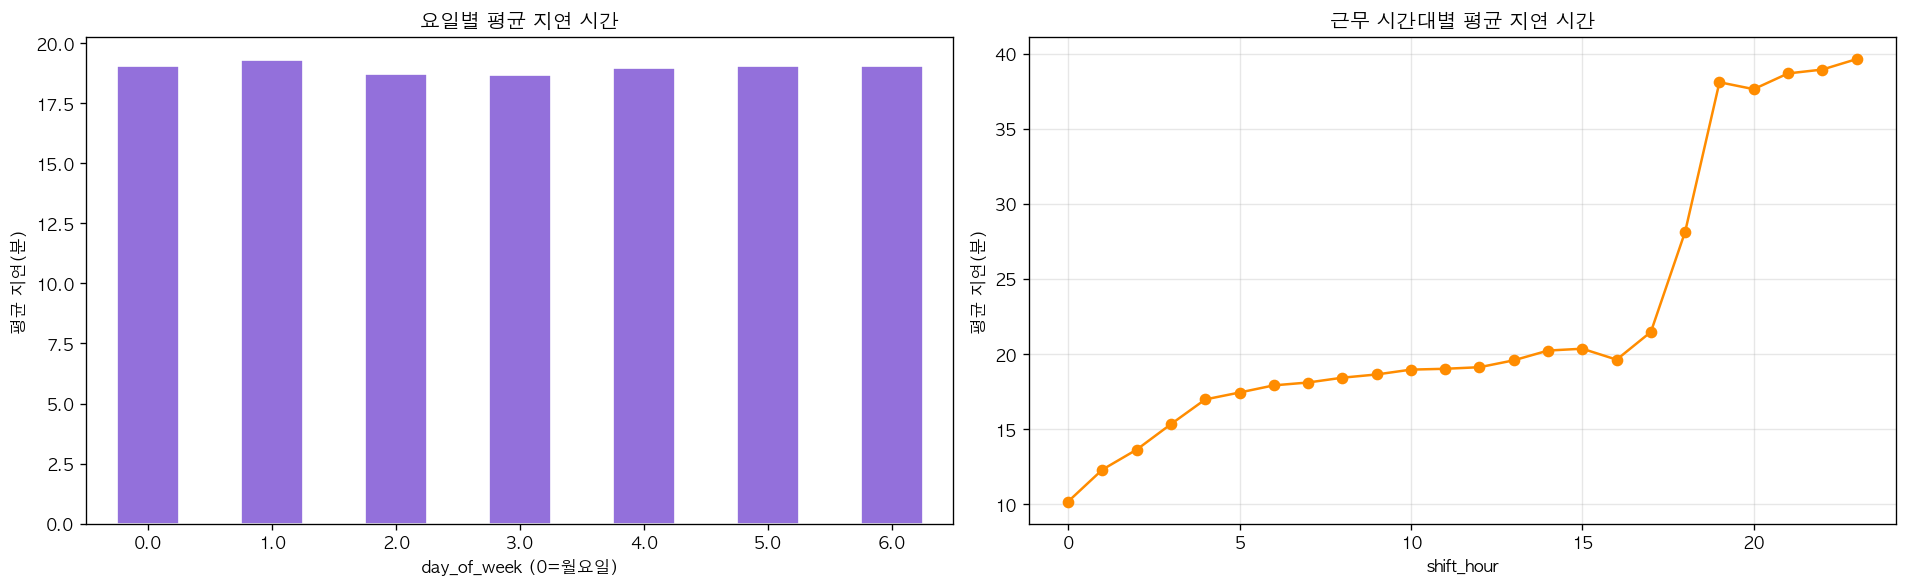

In [15]:
# 요일별 / 근무시간별 패턴
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_stats = train.groupby('day_of_week')[TARGET].mean()
dow_stats.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('요일별 평균 지연 시간', fontsize=12)
axes[0].set_xlabel('day_of_week (0=월요일)')
axes[0].set_ylabel('평균 지연(분)')
axes[0].tick_params(axis='x', rotation=0)

shift_stats = train.groupby('shift_hour')[TARGET].mean()
shift_stats.plot(kind='line', ax=axes[1], marker='o', color='darkorange')
axes[1].set_title('근무 시간대별 평균 지연 시간', fontsize=12)
axes[1].set_xlabel('shift_hour')
axes[1].set_ylabel('평균 지연(분)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

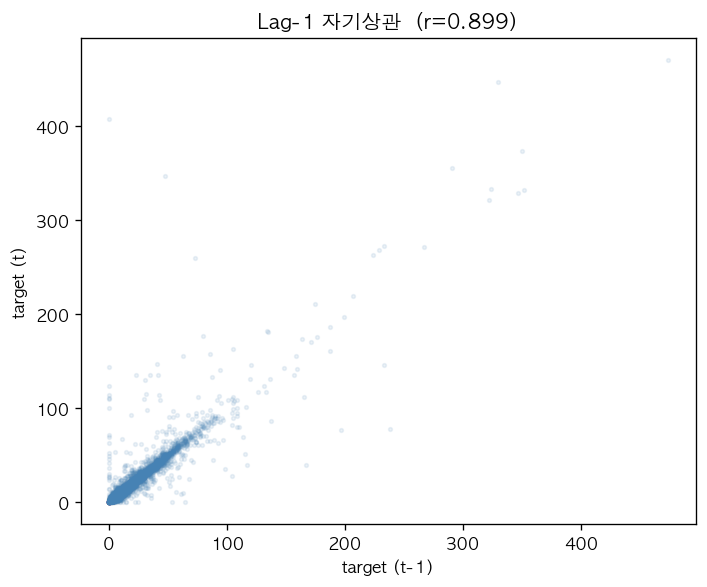

Lag-1 Pearson r = 0.8990


In [16]:
# 시나리오 내 자기상관 — 타겟의 lag-1 관계 확인
train_sorted = train.sort_values(['scenario_id', 'time_step'])
train_sorted['target_lag1'] = train_sorted.groupby('scenario_id')[TARGET].shift(1)

sample = train_sorted.dropna(subset=['target_lag1']).sample(5000, random_state=SEED)

corr_val = sample[[TARGET, 'target_lag1']].corr().iloc[0, 1]

plt.figure(figsize=(6, 5))
plt.scatter(sample['target_lag1'], sample[TARGET], alpha=0.1, s=5, color='steelblue')
plt.xlabel('target (t-1)')
plt.ylabel('target (t)')
plt.title(f'Lag-1 자기상관  (r={corr_val:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Lag-1 Pearson r = {corr_val:.4f}')

## 6. 레이아웃 분석

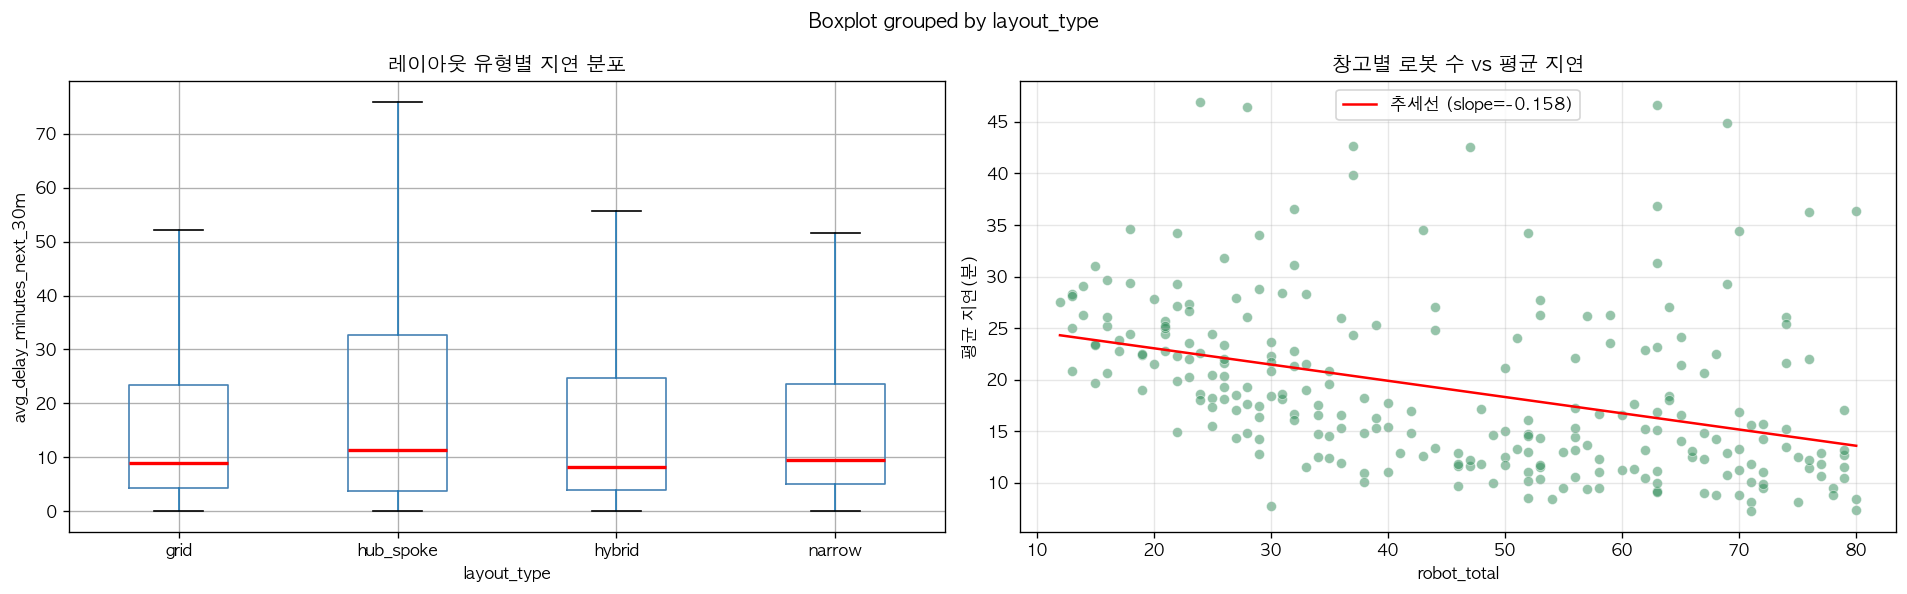

In [17]:
# layout_info merge
train_l = train.merge(layout, on='layout_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 레이아웃 유형별 타겟 분포
order = train_l.groupby('layout_type')[TARGET].median().sort_values().index
train_l.boxplot(
    column=TARGET, by='layout_type',
    ax=axes[0], showfliers=False,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('레이아웃 유형별 지연 분포', fontsize=12)
axes[0].set_xlabel('layout_type')
axes[0].set_ylabel('avg_delay_minutes_next_30m')
plt.sca(axes[0])
plt.xticks(rotation=0)

# 로봇 수 vs 평균 지연
robot_delay = train_l.groupby('layout_id').agg(
    robot_total=('robot_total', 'first'),
    mean_delay=(TARGET, 'mean')
).reset_index()

axes[1].scatter(robot_delay['robot_total'], robot_delay['mean_delay'],
                alpha=0.5, color='seagreen', edgecolors='white', linewidths=0.5)
m, b = np.polyfit(robot_delay['robot_total'], robot_delay['mean_delay'], 1)
x_line = np.linspace(robot_delay['robot_total'].min(), robot_delay['robot_total'].max(), 100)
axes[1].plot(x_line, m*x_line + b, color='red', linewidth=1.5, label=f'추세선 (slope={m:.3f})')
axes[1].set_title('창고별 로봇 수 vs 평균 지연', fontsize=12)
axes[1].set_xlabel('robot_total')
axes[1].set_ylabel('평균 지연(분)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 레이아웃 유형별 평균 지연 통계
train_l.groupby('layout_type')[TARGET].agg(['mean', 'median', 'std', 'count']).round(3)

,mean,median,std,count
layout_type,,,,
grid,18.105,8.924,26.248,91250
hub_spoke,22.280,11.318,30.443,43375
hybrid,18.412,8.250,28.282,73125
narrow,18.361,9.467,24.269,42250


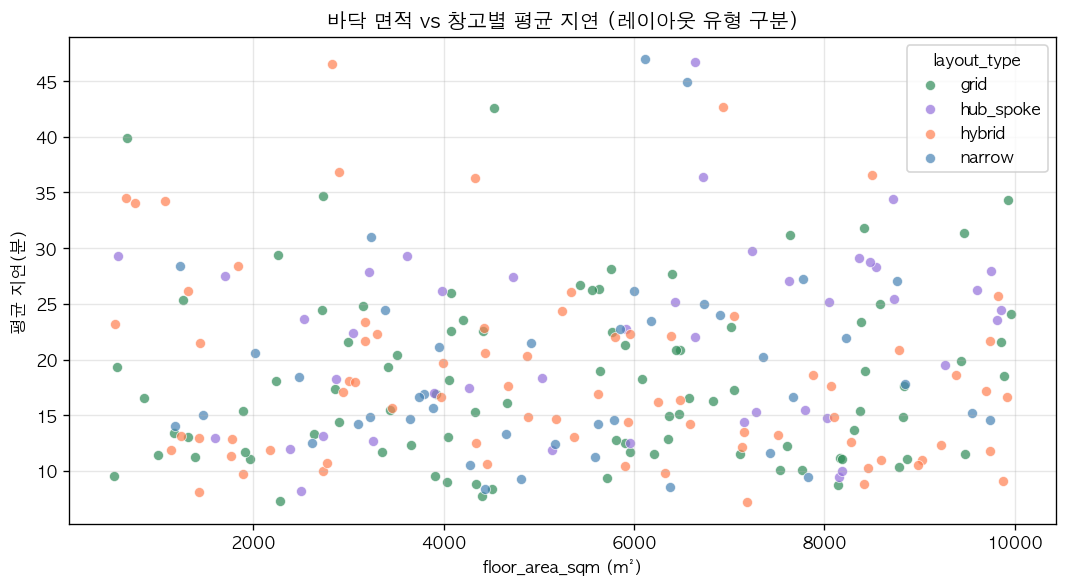

In [19]:
# 바닥 면적 vs 평균 지연
area_delay = train_l.groupby('layout_id').agg(
    floor_area_sqm=('floor_area_sqm', 'first'),
    layout_type=('layout_type', 'first'),
    mean_delay=(TARGET, 'mean')
).reset_index()

colors = {'narrow': 'steelblue', 'grid': 'seagreen', 'hybrid': 'coral', 'hub_spoke': 'mediumpurple'}

plt.figure(figsize=(9, 5))
for lt, grp in area_delay.groupby('layout_type'):
    plt.scatter(grp['floor_area_sqm'], grp['mean_delay'],
                label=lt, color=colors[lt], alpha=0.7, edgecolors='white', linewidths=0.5)
plt.xlabel('floor_area_sqm (m²)')
plt.ylabel('평균 지연(분)')
plt.title('바닥 면적 vs 창고별 평균 지연 (레이아웃 유형 구분)', fontsize=12)
plt.legend(title='layout_type')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 주요 피처 분포 분석

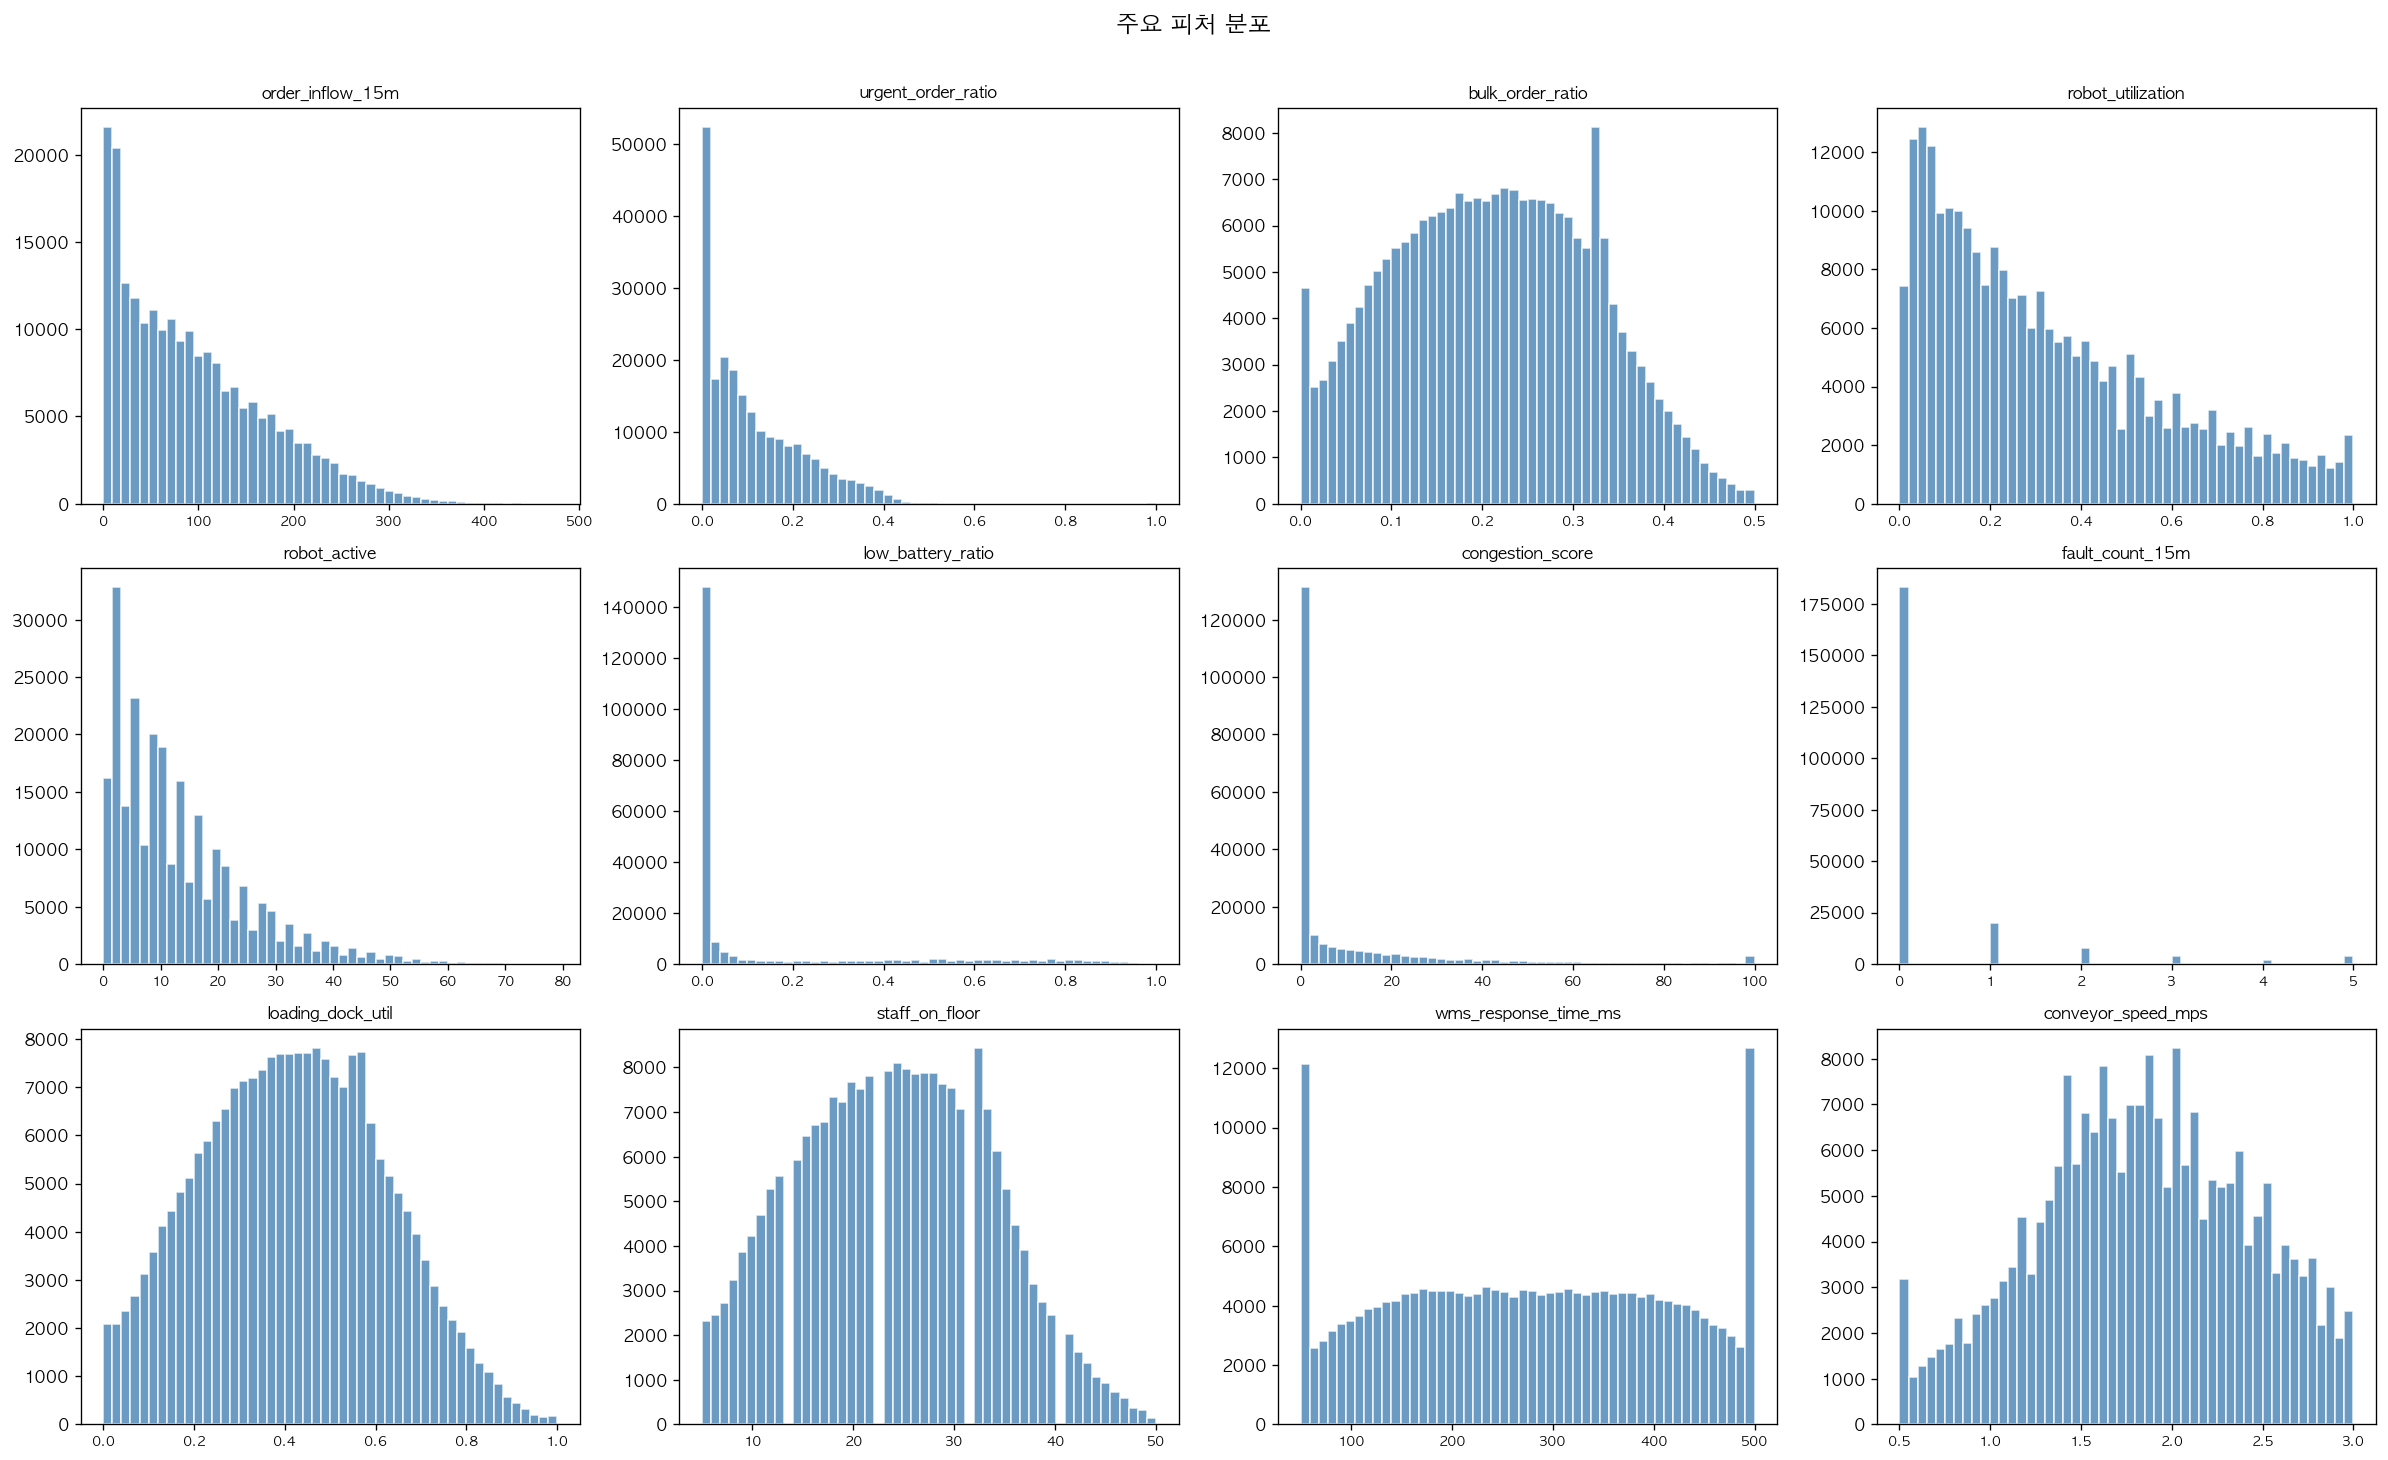

In [20]:
# 주요 카테고리별 대표 피처 선택
key_features = [
    'order_inflow_15m', 'urgent_order_ratio', 'bulk_order_ratio',
    'robot_utilization', 'robot_active', 'low_battery_ratio',
    'congestion_score', 'fault_count_15m', 'loading_dock_util',
    'staff_on_floor', 'wms_response_time_ms', 'conveyor_speed_mps'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    data = train[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('주요 피처 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. 타겟과의 상관관계 분석

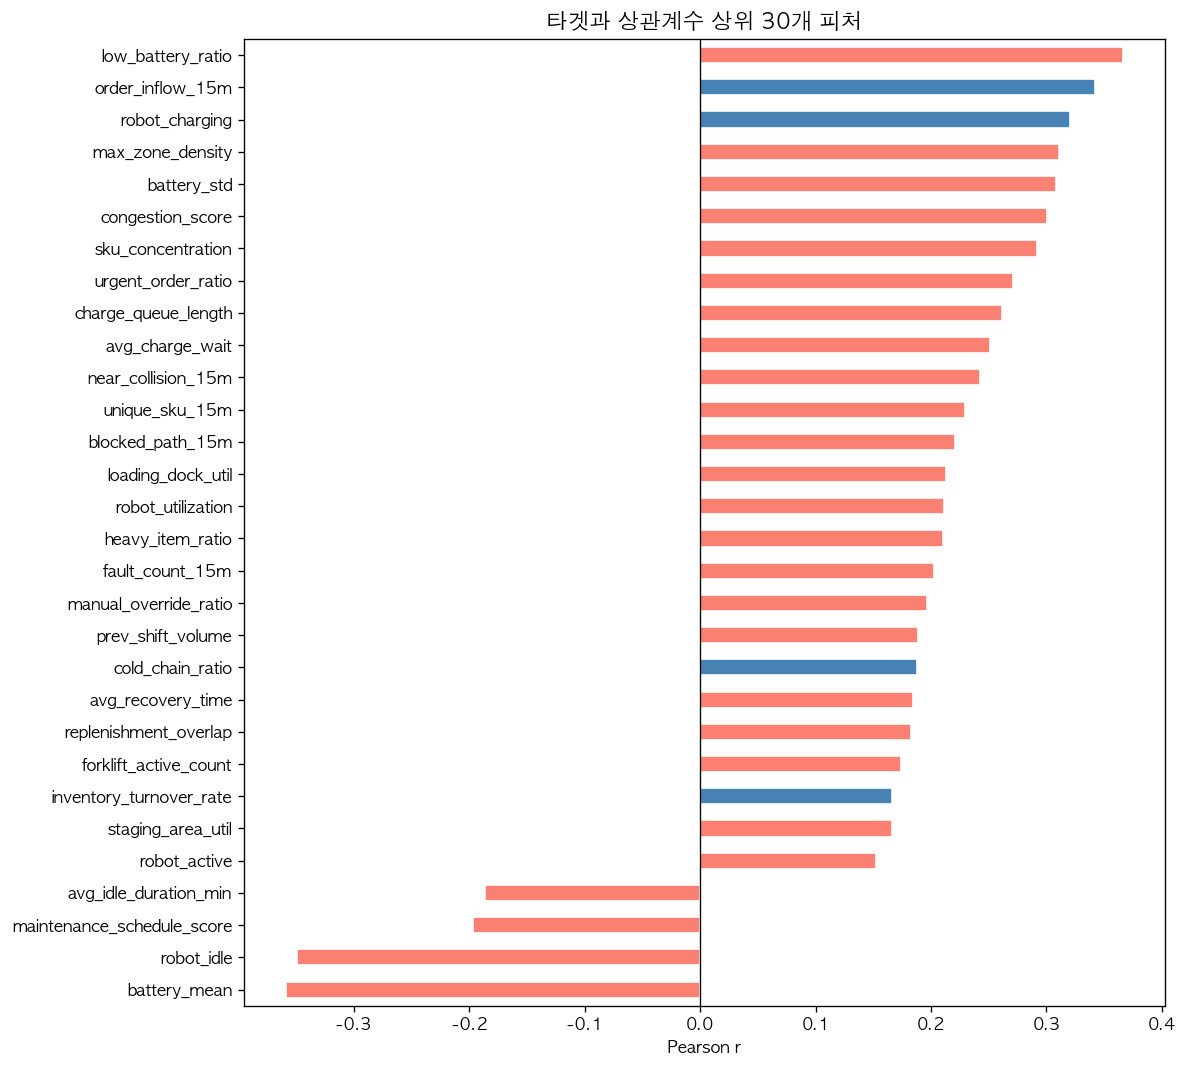

상위 10개:
low_battery_ratio     0.3661
battery_mean         -0.3589
robot_idle           -0.3493
order_inflow_15m      0.3418
robot_charging        0.3204
max_zone_density      0.3108
battery_std           0.3083
congestion_score      0.3004
sku_concentration     0.2919
urgent_order_ratio    0.2711
Name: avg_delay_minutes_next_30m, dtype: float64


In [21]:
num_cols = train[feat_cols].select_dtypes(include='number').columns.tolist()

corr_target = (
    train[num_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

top_n = 30
top_corr = corr_target.head(top_n)

colors = ['salmon' if v > 0 else 'steelblue' for v in top_corr.values]

plt.figure(figsize=(10, 9))
top_corr.sort_values().plot(
    kind='barh', color=colors[::-1], edgecolor='white'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'타겟과 상관계수 상위 {top_n}개 피처', fontsize=13)
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

print('상위 10개:')
print(corr_target.head(10).round(4))

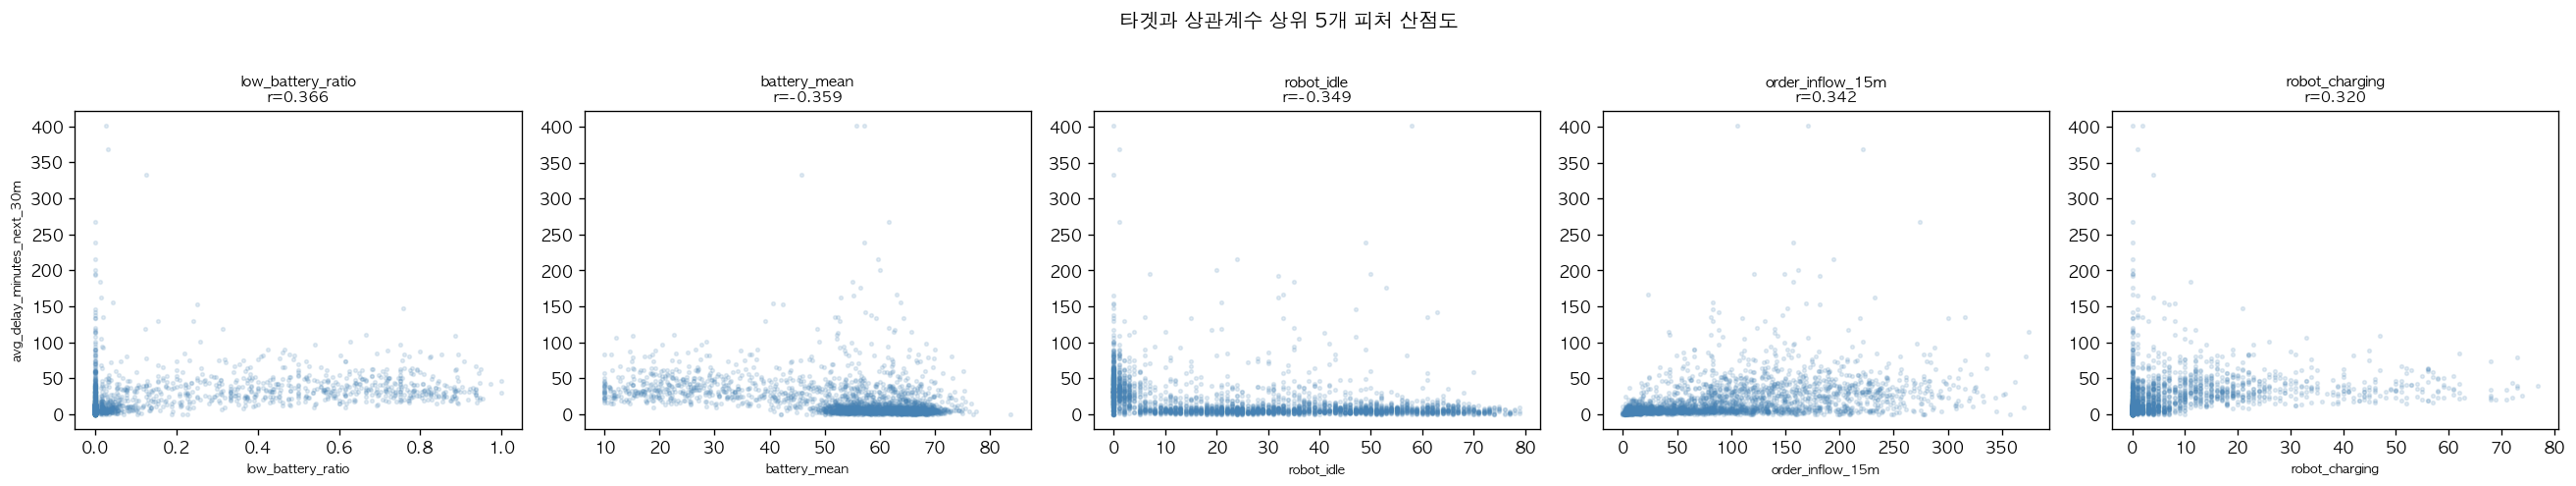

In [22]:
# 상위 상관 피처 scatter (샘플)
top5 = corr_target.head(5).index.tolist()
sample = train.sample(3000, random_state=SEED)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(top5):
    axes[i].scatter(sample[col], sample[TARGET], alpha=0.15, s=5, color='steelblue')
    r = corr_target[col]
    axes[i].set_title(f'{col}\nr={r:.3f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel(TARGET if i == 0 else '', fontsize=8)

plt.suptitle('타겟과 상관계수 상위 5개 피처 산점도', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. 피처 간 다중공선성 (상관 히트맵)

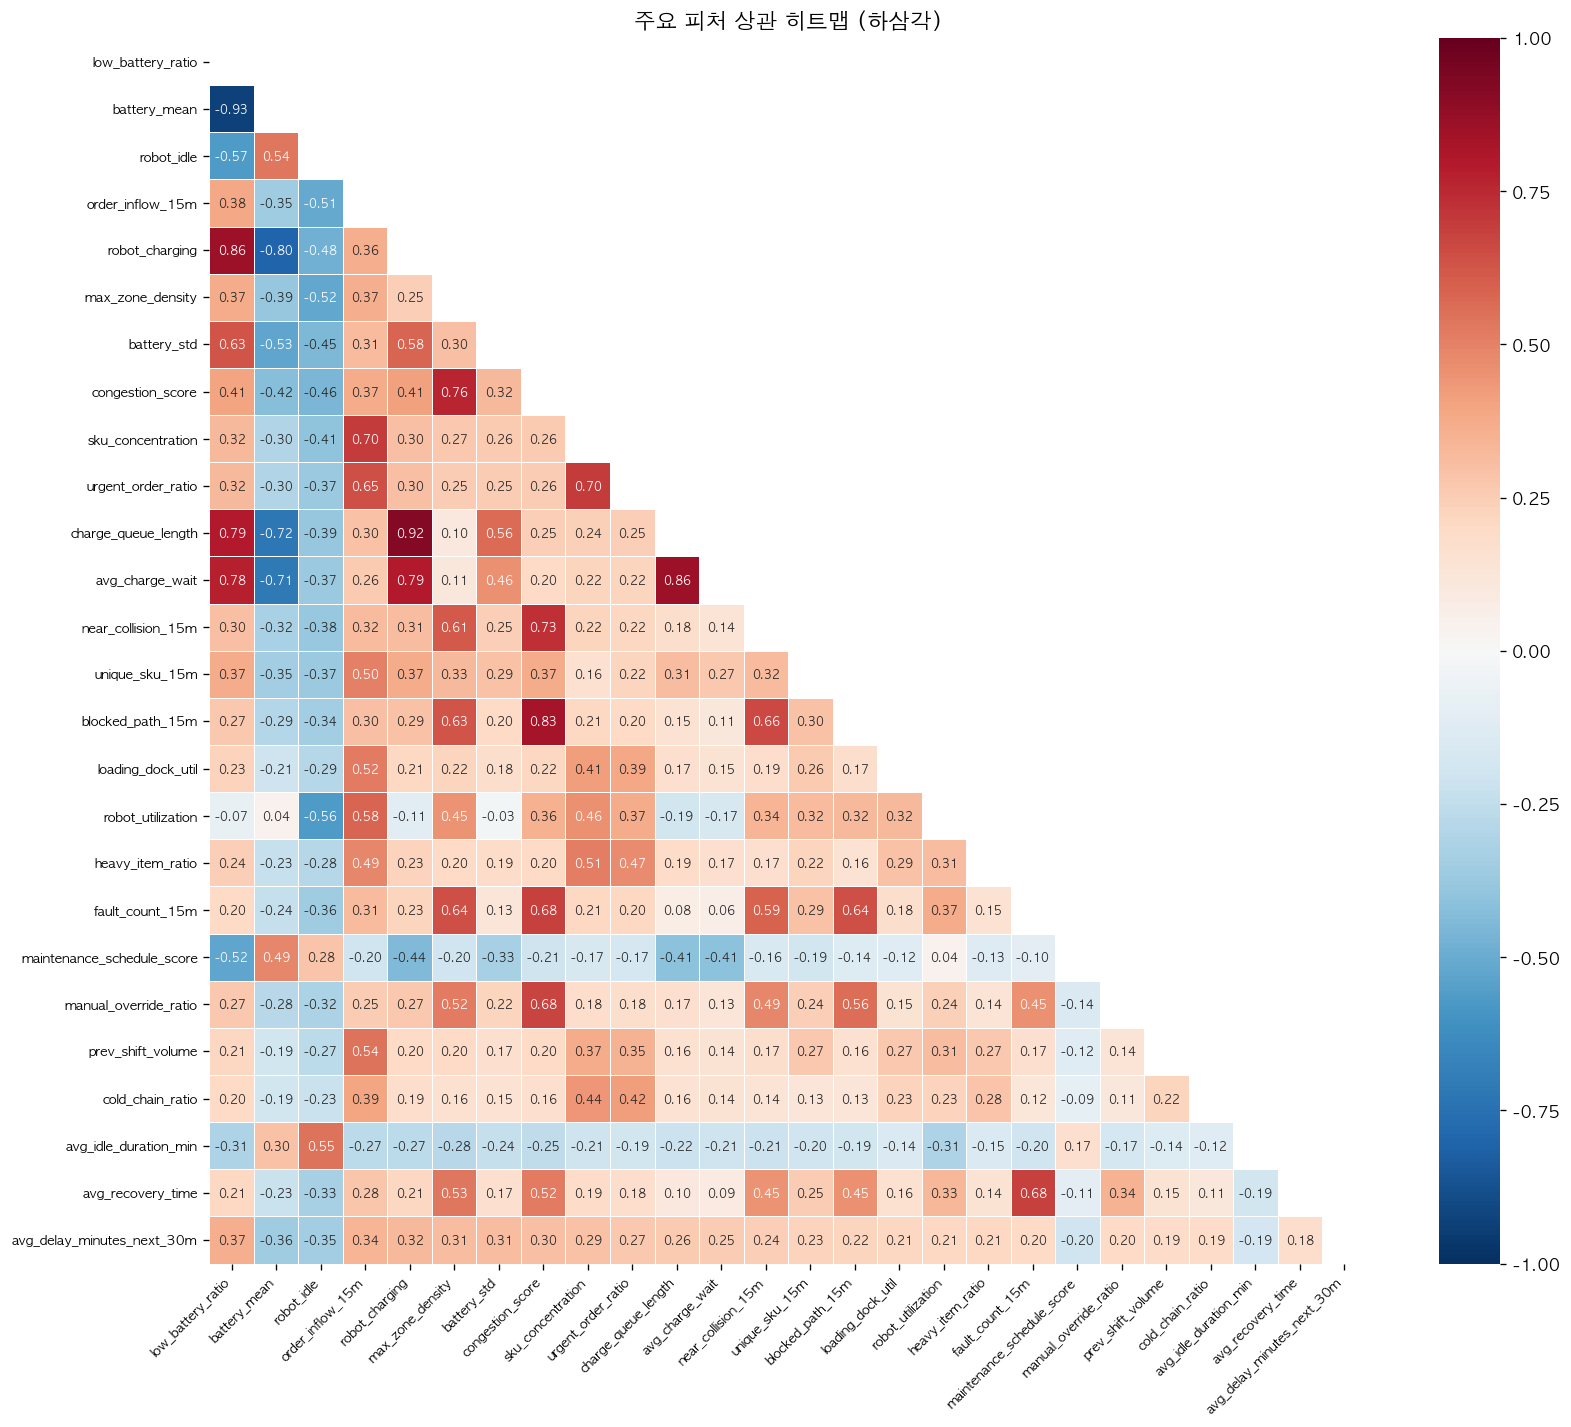

In [23]:
# 타겟과 상관계수 상위 25개 피처만
top25 = corr_target.head(25).index.tolist()
corr_matrix = train[top25 + [TARGET]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 7}
)
plt.title('주요 피처 상관 히트맵 (하삼각)', fontsize=13)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 10. 로봇 / 주문 / 혼잡도 vs 타겟 심층 분석

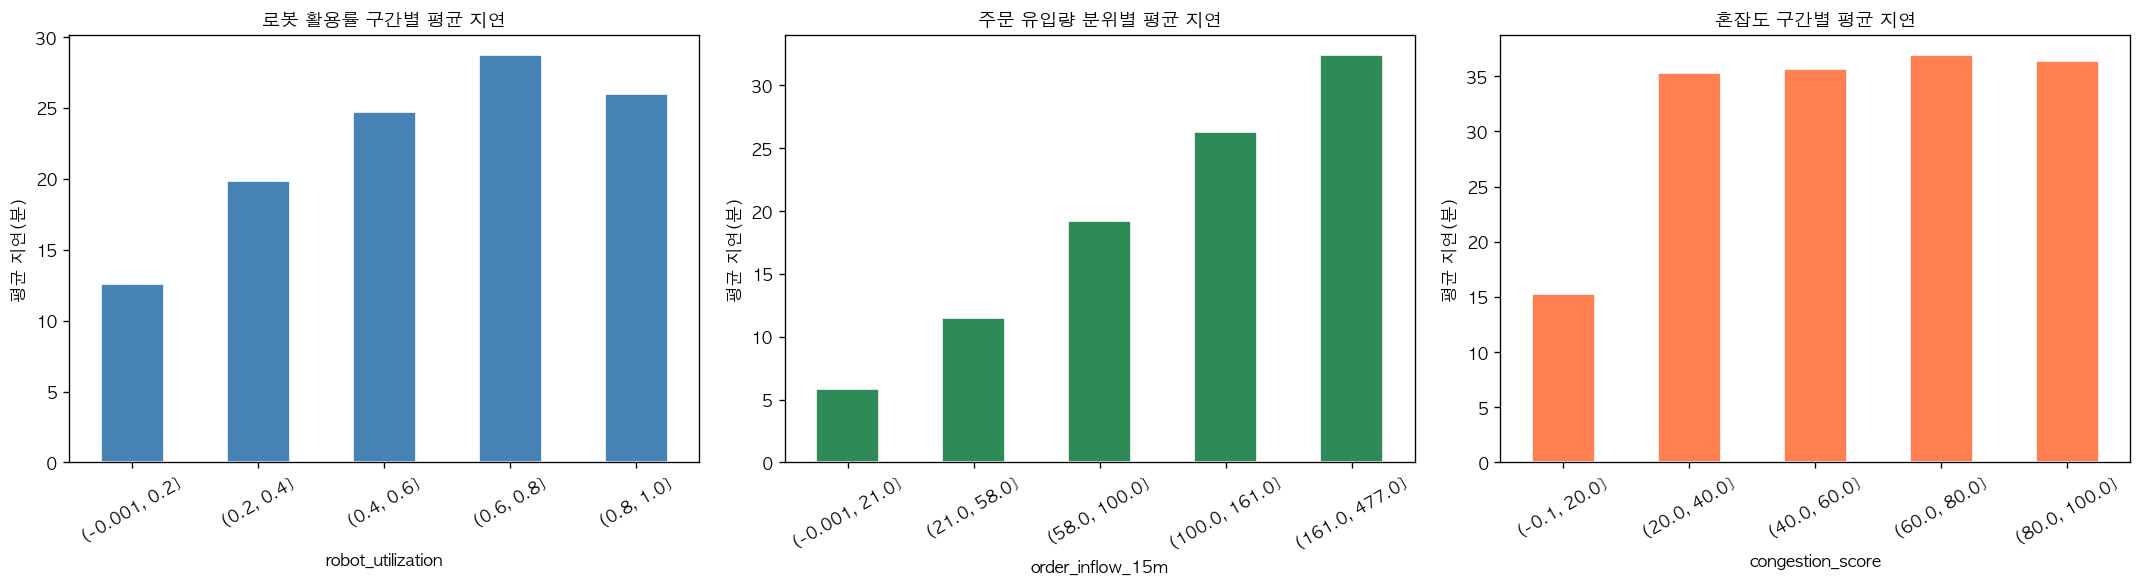

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 로봇 활용률 구간별 지연
train['robot_util_bin'] = pd.cut(train['robot_utilization'], bins=5)
train.groupby('robot_util_bin')[TARGET].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('로봇 활용률 구간별 평균 지연', fontsize=11)
axes[0].set_xlabel('robot_utilization')
axes[0].set_ylabel('평균 지연(분)')
axes[0].tick_params(axis='x', rotation=30)

# 주문 유입량 구간별 지연
train['order_bin'] = pd.qcut(train['order_inflow_15m'], q=5, duplicates='drop')
train.groupby('order_bin')[TARGET].mean().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('주문 유입량 분위별 평균 지연', fontsize=11)
axes[1].set_xlabel('order_inflow_15m')
axes[1].set_ylabel('평균 지연(분)')
axes[1].tick_params(axis='x', rotation=30)

# 혼잡도 구간별 지연
train['cong_bin'] = pd.cut(train['congestion_score'], bins=5)
train.groupby('cong_bin')[TARGET].mean().plot(
    kind='bar', ax=axes[2], color='coral', edgecolor='white'
)
axes[2].set_title('혼잡도 구간별 평균 지연', fontsize=11)
axes[2].set_xlabel('congestion_score')
axes[2].set_ylabel('평균 지연(분)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 임시 컬럼 정리
train.drop(columns=['robot_util_bin', 'order_bin', 'cong_bin'], inplace=True)

## 11. Train / Test 분포 비교

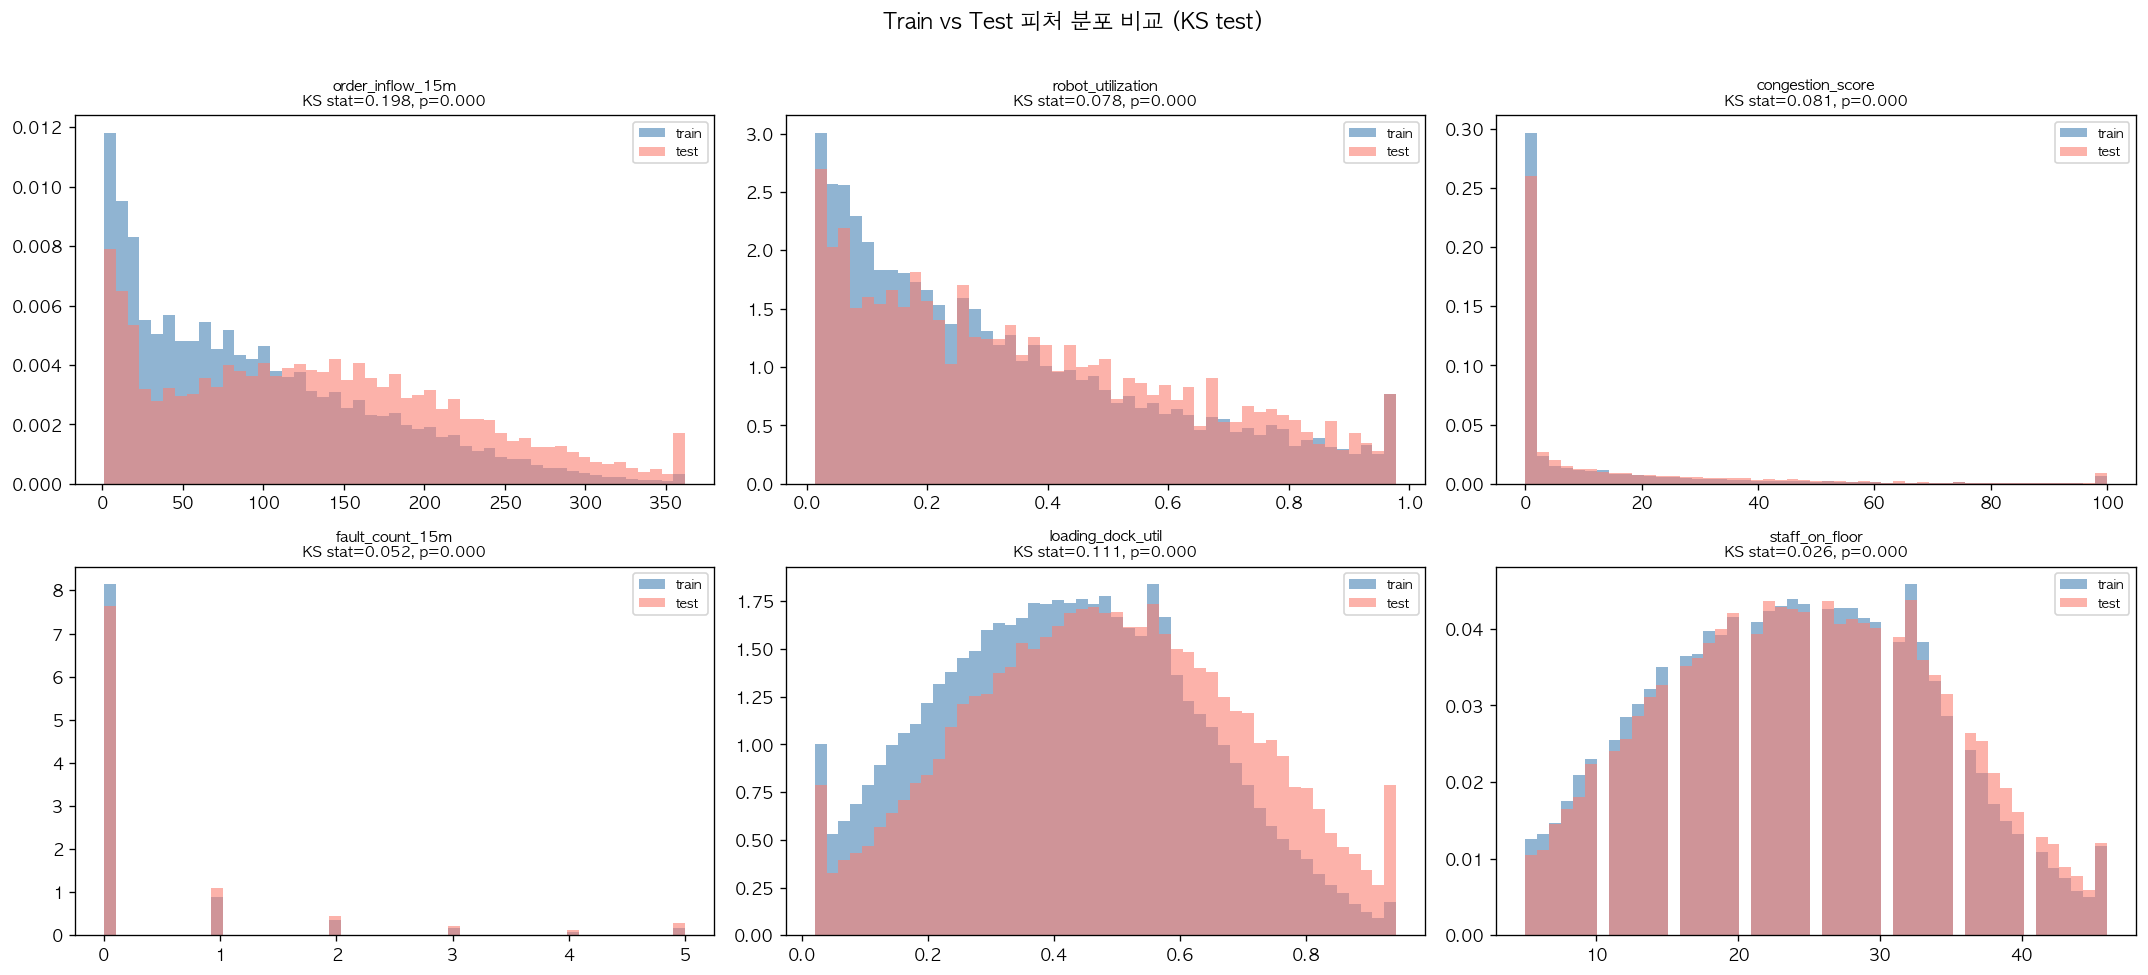

In [25]:
# 주요 피처 train vs test 분포 비교
compare_cols = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m', 'loading_dock_util', 'staff_on_floor'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    tr_data = train[col].dropna()
    te_data = test[col].dropna()
    
    lo = min(tr_data.quantile(0.01), te_data.quantile(0.01))
    hi = max(tr_data.quantile(0.99), te_data.quantile(0.99))
    bins = np.linspace(lo, hi, 50)
    
    axes[i].hist(tr_data.clip(lo, hi), bins=bins, alpha=0.6, label='train', color='steelblue', density=True)
    axes[i].hist(te_data.clip(lo, hi), bins=bins, alpha=0.6, label='test',  color='salmon',   density=True)
    
    # KS test
    ks_stat, ks_p = stats.ks_2samp(tr_data, te_data)
    axes[i].set_title(f'{col}\nKS stat={ks_stat:.3f}, p={ks_p:.3f}', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Train vs Test 피처 분포 비교 (KS test)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. EDA 요약 및 모델링 인사이트

In [26]:
print('=' * 60)
print('EDA 핵심 인사이트')
print('=' * 60)

print(f"""
[데이터 구조]
- train {train.shape} / test {test.shape} / layout {layout.shape}
- 시나리오 {train['scenario_id'].nunique():,}개, 창고 {train['layout_id'].nunique()}개
- 시나리오당 중앙값 타임스텝 수: {train.groupby('scenario_id').size().median()}

[타겟 변수]
- mean={y.mean():.2f}, median={y.median():.2f}, std={y.std():.2f}
- 우측 꼬리 분포 (skewness={y.skew():.2f}) → log1p 변환 고려
- 음수값 비율: {(y < 0).mean()*100:.2f}% → clip(lower=0) 또는 그대로 학습

[결측값]
- 결측 있는 피처: {(train[feat_cols].isnull().sum() > 0).sum()}개
- LightGBM은 결측 자체 처리 가능 → 단순 fillna 불필요
- 딥러닝 적용 시 median/mean imputation 필요

[시계열 패턴]
- Lag-1 자기상관 r={corr_val:.3f} → Lag 피처 중요
- 특정 타임스텝에서 지연 증가 패턴 존재 → rolling 피처 효과적

[레이아웃]
- 레이아웃 유형(layout_type)에 따라 지연 분포 차이 존재
- layout_info.csv merge는 필수 (robot_total, floor_area_sqm 등 유의미)

[모델링 권고사항]
1. scenario_id 기반 Group K-Fold 필수 (데이터 누수 방지)
2. Lag(t-1, t-2, t-3) + Rolling(3, 5) 피처 생성
3. layout_info merge 후 layout_type one-hot 또는 label 인코딩
4. 타겟 log1p 변환 실험 권장 (우측 꼬리 완화)
5. 상관계수 낮은 피처 (~0.01 미만) 제거 검토
""")

EDA 핵심 인사이트

[데이터 구조]
- train (250000, 95) / test (50000, 93) / layout (300, 15)
- 시나리오 10,000개, 창고 250개
- 시나리오당 중앙값 타임스텝 수: 25.0

[타겟 변수]
- mean=18.96, median=9.03, std=27.35
- 우측 꼬리 분포 (skewness=5.68) → log1p 변환 고려
- 음수값 비율: 0.00% → clip(lower=0) 또는 그대로 학습

[결측값]
- 결측 있는 피처: 86개
- LightGBM은 결측 자체 처리 가능 → 단순 fillna 불필요
- 딥러닝 적용 시 median/mean imputation 필요

[시계열 패턴]
- Lag-1 자기상관 r=0.899 → Lag 피처 중요
- 특정 타임스텝에서 지연 증가 패턴 존재 → rolling 피처 효과적

[레이아웃]
- 레이아웃 유형(layout_type)에 따라 지연 분포 차이 존재
- layout_info.csv merge는 필수 (robot_total, floor_area_sqm 등 유의미)

[모델링 권고사항]
1. scenario_id 기반 Group K-Fold 필수 (데이터 누수 방지)
2. Lag(t-1, t-2, t-3) + Rolling(3, 5) 피처 생성
3. layout_info merge 후 layout_type one-hot 또는 label 인코딩
4. 타겟 log1p 변환 실험 권장 (우측 꼬리 완화)
5. 상관계수 낮은 피처 (~0.01 미만) 제거 검토

